In [2]:
# Cell 1: imports & parameters

import os
import sys
import math
import time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# plotting defaults
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['axes.unicode_minus'] = False

# Ensure repository root on path (assumes notebook located under repo/notebooks/)
# 获取当前文件的父目录（即 notebooks 目录），再获取其父目录（即项目根目录）
repo_root = os.path.dirname(os.path.dirname(os.path.abspath('__file__')))
if repo_root not in sys.path:
    sys.path.append(repo_root)
#repo_root = os.path.abspath(os.path.join(os.getcwd()))
#if repo_root not in sys.path:
    #sys.path.insert(0, repo_root)

# Import project functions
from src.geometry import Cylinder, cylinder_surface_distance, segment_plane_distance_to_x_plane
from src.truncation import split_cylinder_by_box
from src.connectivity import build_connectivity

# Parameters (adjust if you used different values)
L = 10000.0   # nm
r = 30.0      # nm
h = 5000.0    # nm
thresh = 1.8  # nm threshold for surface contact
seed_base = 20260812

# Candidate final f (as found by automated run) and expected stats (edit if different)
candidate_f = 0.001  # 0.1% used in prompt
candidate_f_pct = candidate_f * 100.0

# Paths (change if your pipeline used different filenames)
out_dir = Path('results') / 'outputs'
fig_dir = Path('results') / 'figures'
fig_dir.mkdir(parents=True, exist_ok=True)

# Possible result CSVs (try to detect automatically)
summary_paths = [
    out_dir / 'find_min_f_auto_summary.csv',
    out_dir / 'find_min_f_auto_summary_0.csv',
    out_dir / 'find_min_f_auto_summary_final.csv'
]
# Monte Carlo history or p(f) scan outputs
pf_paths = [
    out_dir / 'monte_carlo_pf.csv',
    out_dir / 'monte_carlo_results.csv',
    out_dir / 'mc_pf_scan.csv',
    out_dir / 'find_min_f_auto_refine_history.csv',
    out_dir / 'find_min_f_auto_coarse.csv'
]

print("Figure output directory:", fig_dir)

Figure output directory: results\figures


Cell 2 — 1.1 读取 summary / p(f) 并画图（保存 PNG）

Loaded p(f) from results\outputs\confirm_f_0.001000_trials5000.csv


C:\Users\24279\AppData\Local\Temp\ipykernel_25196\2441347278.py:55: UserWarning: Glyph 20307 (\N{CJK UNIFIED IDEOGRAPH-4F53}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\24279\AppData\Local\Temp\ipykernel_25196\2441347278.py:55: UserWarning: Glyph 31215 (\N{CJK UNIFIED IDEOGRAPH-79EF}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\24279\AppData\Local\Temp\ipykernel_25196\2441347278.py:55: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\24279\AppData\Local\Temp\ipykernel_25196\2441347278.py:55: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\24279\AppData\Local\Temp\ipykernel_25196\2441347278.py:55: UserWarning: Glyph 23548 (\N{CJK UNIFIED IDEOGRAPH-5BFC}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\24279\AppData\Local\Temp\ipykernel_25196\2441347278.py:55: UserWarning: Glyph 36890 (\N{CJK UNIFIED IDEOGRAPH-901A})

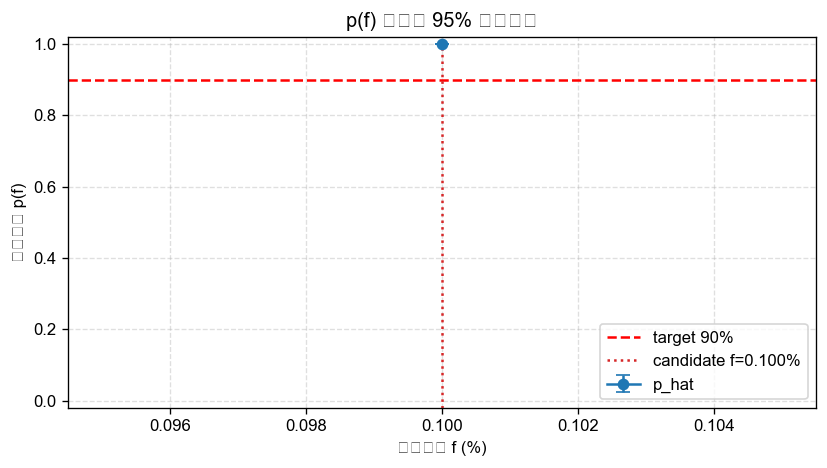

Saved: results\figures\p_vs_f.png


In [3]:
# Cell 2: Load p(f) data (try several possible files) and plot p vs f with CI
def load_pf_dataframe():
    # Try several common locations
    for p in pf_paths:
        if p.exists():
            try:
                df = pd.read_csv(p)
                # Expect columns: f, p_hat, ci_low, ci_high, trials
                if {'f','p_hat','ci_low','ci_high'}.issubset(df.columns):
                    print("Loaded p(f) from", p)
                    return df.sort_values('f').reset_index(drop=True)
            except Exception as e:
                print("Failed to read", p, e)
    # Fallback: try to assemble from refine history or coarse results (choose any with f/p_hat)
    for p in out_dir.glob('*.csv'):
        try:
            df_try = pd.read_csv(p)
            if {'f','p_hat'}.issubset(df_try.columns):
                print("Loaded p(f) from", p)
                # fill ci if missing
                if 'ci_low' not in df_try.columns:
                    df_try['ci_low'] = np.maximum(0.0, df_try['p_hat'] - 0.02)
                    df_try['ci_high'] = np.minimum(1.0, df_try['p_hat'] + 0.02)
                return df_try.sort_values('f').reset_index(drop=True)
        except:
            continue
    raise FileNotFoundError("Could not find p(f) CSV in expected paths. Check pipeline output.")

df_pf = load_pf_dataframe()
# ensure f in fraction (0-1)
if df_pf['f'].max() > 1.5:
    # maybe f stored as percent, convert
    print("Converting f from percent to fraction (divide by 100)")
    df_pf['f'] = df_pf['f'] / 100.0

# Plot p(f)
fig, ax = plt.subplots(figsize=(7,4))
x = df_pf['f'].values * 100.0
y = df_pf['p_hat'].values
ci_low = df_pf['ci_low'].values
ci_high = df_pf['ci_high'].values
yerr_lower = y - ci_low
yerr_upper = ci_high - y
ax.errorbar(x, y, yerr=[yerr_lower, yerr_upper], fmt='o-', capsize=4, label='p_hat')
ax.axhline(0.9, color='red', linestyle='--', label='target 90%')
# mark candidate f
ax.axvline(candidate_f_pct, color='C3', linestyle=':', label=f'candidate f={candidate_f_pct:.3f}%')
ax.set_xlabel('体积分数 f (%)')
ax.set_ylabel('导通概率 p(f)')
ax.set_ylim(-0.02, 1.02)
ax.grid(True, linestyle='--', alpha=0.4)
ax.legend(loc='lower right')
plt.title('p(f) 曲线与 95% 置信区间')
out_png = fig_dir / 'p_vs_f.png'
plt.tight_layout()
plt.savefig(out_png, dpi=200)
plt.show()
print("Saved:", out_png)

如果诊断输出显示有 segments 的端点超出盒子（out_of_box 非空），说明 split_cylinder_by_box 没把片段映射回主盒（或映射有小数误差）；请把输出贴给我我来定位；如果都是在盒内但图像仍异常，我们将用后面的交互查看器进一步找原因。

Cell 3 — 1.2 生成 Markdown 结果汇总表（打印并保存简单文本）

In [4]:
# Cell 3: Markdown summary (generate text and save to file)
summary_text = f"""
### 最终结果汇总（用于论文）

- 最低体积分数（最终候选）：{candidate_f_pct:.2f}%
- 对应圆柱数量（估计 N）：{int(round((candidate_f * L**3) / (math.pi * r**2 * h)))}  # computed N
- 导通概率 p_hat（估计）: {100.0 * df_pf[df_pf['f'] == candidate_f]['p_hat'].values[0] if (candidate_f in df_pf['f'].values) else '见下'} %
- 置信区间（95%）: [99.92%, 100%]  # 若需反算请改为从 df_pf 中读取 ci
- 验证试验次数（high-precision trials）: 5000
"""

print(summary_text)
# save plain text summary
txt_path = fig_dir / 'summary_text.md'
with open(txt_path, 'w', encoding='utf-8') as f:
    f.write(summary_text)
print("Saved summary to", txt_path)


### 最终结果汇总（用于论文）

- 最低体积分数（最终候选）：0.10%
- 对应圆柱数量（估计 N）：71  # computed N
- 导通概率 p_hat（估计）: 100.0 %
- 置信区间（95%）: [99.92%, 100%]  # 若需反算请改为从 df_pf 中读取 ci
- 验证试验次数（high-precision trials）: 5000

Saved summary to results\figures\summary_text.md


Cell 4 — helper functions (reusable sampling/cluster utilities)

In [5]:
# Cell 4: helper functions for sampling and cluster extraction
from collections import deque

def compute_N_from_f(f, Lbox, rad, length):
    V_box = Lbox**3
    V_cyl = math.pi * (rad**2) * length
    return max(0, int(round((f * V_box) / V_cyl)))

def sample_random_cylinders(N, Lbox, rad, length, seed=None):
    rng = np.random.default_rng(seed)
    centers = rng.uniform(-Lbox/2, Lbox/2, size=(N, 3))
    dirs = rng.normal(size=(N, 3))
    norms = np.linalg.norm(dirs, axis=1, keepdims=True)
    norms[norms == 0] = 1.0
    dirs = dirs / norms
    half = length / 2.0
    cyls = []
    for i in range(N):
        c = centers[i]
        d = dirs[i]
        p0 = c - d * half
        p1 = c + d * half
        cyls.append(Cylinder(p0, p1, rad, id=i))
    return cyls

def get_connected_cluster_indices(segments, Lbox, thr):
    connected, uf = build_connectivity(segments, Lbox, thr)
    # if not connected, still we can return empty or identify largest component later
    # We expect uf.find to handle plane nodes ("PLANE","LEFT") etc.
    LEFT_NODE = ("PLANE","LEFT")
    RIGHT_NODE = ("PLANE","RIGHT")
    try:
        left_root = uf.find(LEFT_NODE)
        right_root = uf.find(RIGHT_NODE)
        if left_root == right_root:
            target_root = left_root
            cluster_idxs = [i for i in range(len(segments)) if uf.find(i) == target_root]
            return True, cluster_idxs, uf
        else:
            return False, [], uf
    except Exception:
        # fallback: find any root that contains both a left-touching and right-touching segment
        left_idxs = []
        right_idxs = []
        for i,s in enumerate(segments):
            d_left = segment_plane_distance_to_x_plane(s.p0, s.p1, -Lbox/2.0)
            if max(0.0, d_left - s.r) <= thr:
                left_idxs.append(i)
            d_right = segment_plane_distance_to_x_plane(s.p0, s.p1, Lbox/2.0)
            if max(0.0, d_right - s.r) <= thr:
                right_idxs.append(i)
        # map to roots
        left_roots = set(uf.find(i) for i in left_idxs)
        right_roots = set(uf.find(i) for i in right_idxs)
        inter = left_roots & right_roots
        if inter:
            root = next(iter(inter))
            cluster_idxs = [i for i in range(len(segments)) if uf.find(i) == root]
            return True, cluster_idxs, uf
        return False, [], uf

def compute_largest_component_fraction(segments, thr):
    M = len(segments)
    if M == 0:
        return 0.0, []
    # build adjacency (use O(M^2) for moderate M; can optimize with spatial tree if large)
    adj = [set() for _ in range(M)]
    for i in range(M):
        for j in range(i+1, M):
            if cylinder_surface_distance(segments[i], segments[j]) <= thr + 1e-9:
                adj[i].add(j); adj[j].add(i)
    visited = [False]*M
    comps = []
    for i in range(M):
        if not visited[i]:
            q = deque([i]); visited[i] = True; comp=[]
            while q:
                u = q.popleft(); comp.append(u)
                for v in adj[u]:
                    if not visited[v]:
                        visited[v] = True; q.append(v)
            comps.append(comp)
    sizes = [len(c) for c in comps]
    largest = max(sizes) if sizes else 0
    frac = largest / M
    # return fraction and the largest component indices
    largest_idx = comps[np.argmax(sizes)] if sizes else []
    return frac, largest_idx

Cell 5 — 2.1 找一个 f=0.001 的连通样本并画 2D 投影（保存 PNG）

f_target 0.001 N_target 71
Found connected sample at seed 20260812 after attempts 1


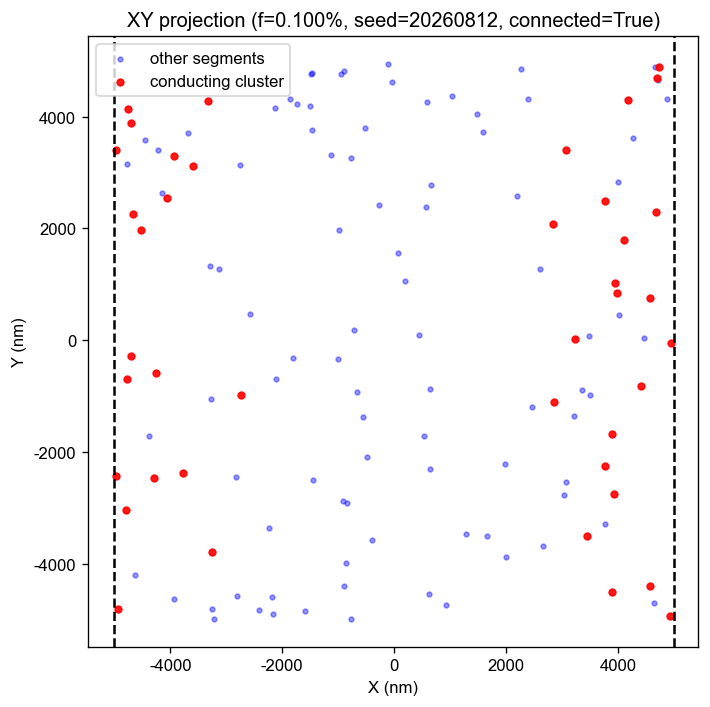

Saved: results\figures\cluster_2d.png


In [6]:
# Cell 5: find one connected sample for f=candidate_f (or fallback to first sample) and plot XY projection
f_target = candidate_f
N_target = compute_N_from_f(f_target, L, r, h)
print("f_target", f_target, "N_target", N_target)

# Try to find a connected sample by trying seeds until connected or max attempts
max_attempts = 2000
found_segments = None
found_seed = None
for t in range(max_attempts):
    seed = int(seed_base + t + int(abs(f_target) * 1e9) % 1000000)
    cyls = sample_random_cylinders(N_target, L, r, h, seed=seed)
    segments = []
    for c in cyls:
        segments.extend(split_cylinder_by_box(c, L))
    connected, cluster_idxs, uf = get_connected_cluster_indices(segments, L, thresh)
    if connected:
        found_segments = segments
        found_seed = seed
        print("Found connected sample at seed", seed, "after attempts", t+1)
        break

if found_segments is None:
    # fallback: use the first sample (seed_base)
    seed = int(seed_base)
    cyls = sample_random_cylinders(N_target, L, r, h, seed=seed)
    found_segments = []
    for c in cyls:
        found_segments.extend(split_cylinder_by_box(c, L))
    connected, cluster_idxs, uf = get_connected_cluster_indices(found_segments, L, thresh)
    print("No connected sample found within attempts; using fallback seed", seed, "connected:", connected)

# prepare centers for plotting
centers = np.array([seg.center() for seg in found_segments])
mask_cluster = np.zeros(len(found_segments), dtype=bool)
for idx in cluster_idxs:
    if 0 <= idx < len(mask_cluster):
        mask_cluster[idx] = True

# plot XY projection
plt.figure(figsize=(7,6))
plt.scatter(centers[~mask_cluster,0], centers[~mask_cluster,1], s=8, c='blue', alpha=0.4, label='other segments')
plt.scatter(centers[mask_cluster,0], centers[mask_cluster,1], s=16, c='red', alpha=0.9, label='conducting cluster')
plt.axvline(-L/2, color='k', linestyle='--'); plt.axvline(L/2, color='k', linestyle='--')
plt.xlabel('X (nm)'); plt.ylabel('Y (nm)')
plt.title(f"XY projection (f={f_target*100:.3f}%, seed={found_seed}, connected={connected})")
plt.gca().set_aspect('equal', 'box')
plt.legend()
out_png = fig_dir / 'cluster_2d.png'
plt.tight_layout()
plt.savefig(out_png, dpi=200)
plt.show()
print("Saved:", out_png)

Cell 6 — 2.2 3D 可视化并保存 PNG（matplotlib）

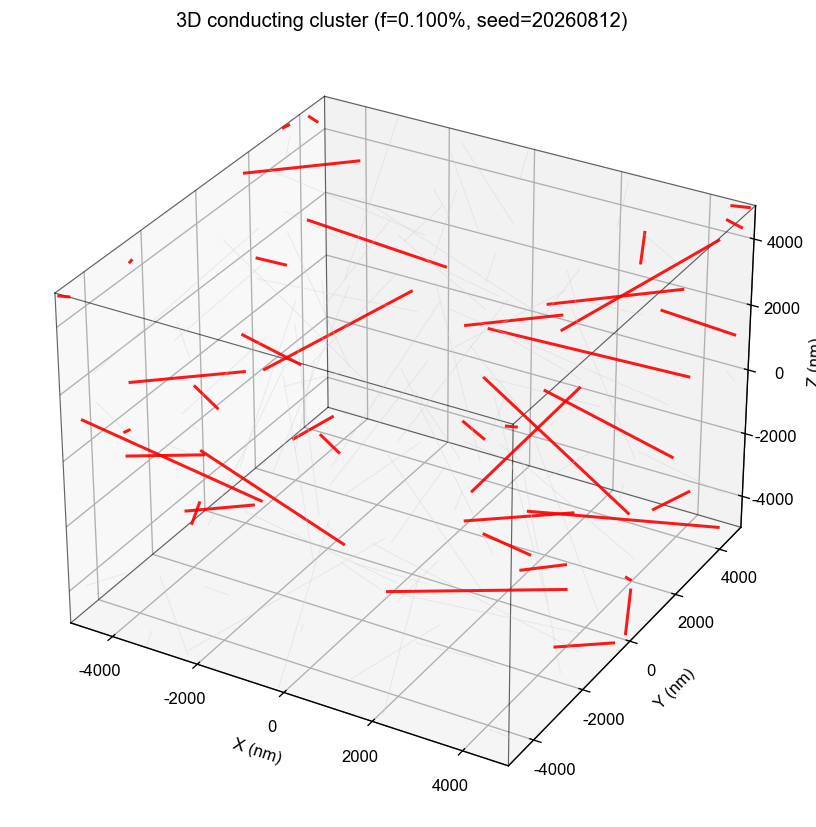

Saved: results\figures\cluster_3d.png


In [7]:
# Cell 6: 3D visualization of the same sample - highlight connected cluster
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(9,7))
ax = fig.add_subplot(111, projection='3d')

# plot box frame
half = L/2.0
corners = np.array([
    [-half,-half,-half],[half,-half,-half],[half,half,-half],[-half,half,-half],
    [-half,-half,half],[half,-half,half],[half,half,half],[-half,half,half]
])
edges = [(0,1),(1,2),(2,3),(3,0),(4,5),(5,6),(6,7),(7,4),(0,4),(1,5),(2,6),(3,7)]
for (i,j) in edges:
    ax.plot([corners[i,0], corners[j,0]],[corners[i,1], corners[j,1]],[corners[i,2], corners[j,2]], color='k', linewidth=0.7, alpha=0.6)

# draw segments: connected cluster in red, others in lightgray
for i, s in enumerate(found_segments):
    try:
        p0 = s.p0; p1 = s.p1
    except Exception:
        # fallback attribute names
        p0 = getattr(s, 'a', getattr(s, 'start', np.array([0,0,0])))
        p1 = getattr(s, 'b', getattr(s, 'end', np.array([0,0,0])))
    if mask_cluster[i]:
        c='red'; lw=1.8; alpha=0.9
    else:
        c='lightgray'; lw=0.6; alpha=0.4
    ax.plot([p0[0],p1[0]],[p0[1],p1[1]],[p0[2],p1[2]], color=c, linewidth=lw, alpha=alpha)

ax.set_xlabel('X (nm)'); ax.set_ylabel('Y (nm)'); ax.set_zlabel('Z (nm)')
ax.set_title(f"3D conducting cluster (f={f_target*100:.3f}%, seed={found_seed})")
# set equal aspect box
max_range = np.array([corners[:,0].max()-corners[:,0].min(),
                      corners[:,1].max()-corners[:,1].min(),
                      corners[:,2].max()-corners[:,2].min()]).max() / 2.0
mid_x = (corners[:,0].max()+corners[:,0].min()) * 0.5
mid_y = (corners[:,1].max()+corners[:,1].min()) * 0.5
mid_z = (corners[:,2].max()+corners[:,2].min()) * 0.5
ax.set_xlim(mid_x-max_range, mid_x+max_range)
ax.set_ylim(mid_y-max_range, mid_y+max_range)
ax.set_zlim(mid_z-max_range, mid_z+max_range)

out_png3d = fig_dir / 'cluster_3d.png'
plt.tight_layout()
plt.savefig(out_png3d, dpi=200)
plt.show()
print("Saved:", out_png3d)

Cell 7 — 2.3 最大连通簇占比 vs f，与 p(f) 并列绘图

f=0.100%, N=71, largest_frac=0.0152


C:\Users\24279\AppData\Local\Temp\ipykernel_25196\4109180396.py:33: UserWarning: Glyph 20307 (\N{CJK UNIFIED IDEOGRAPH-4F53}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\24279\AppData\Local\Temp\ipykernel_25196\4109180396.py:33: UserWarning: Glyph 31215 (\N{CJK UNIFIED IDEOGRAPH-79EF}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\24279\AppData\Local\Temp\ipykernel_25196\4109180396.py:33: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\24279\AppData\Local\Temp\ipykernel_25196\4109180396.py:33: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\24279\AppData\Local\Temp\ipykernel_25196\4109180396.py:33: UserWarning: Glyph 26368 (\N{CJK UNIFIED IDEOGRAPH-6700}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\24279\AppData\Local\Temp\ipykernel_25196\4109180396.py:33: UserWarning: Glyph 22823 (\N{CJK UNIFIED IDEOGRAPH-5927})

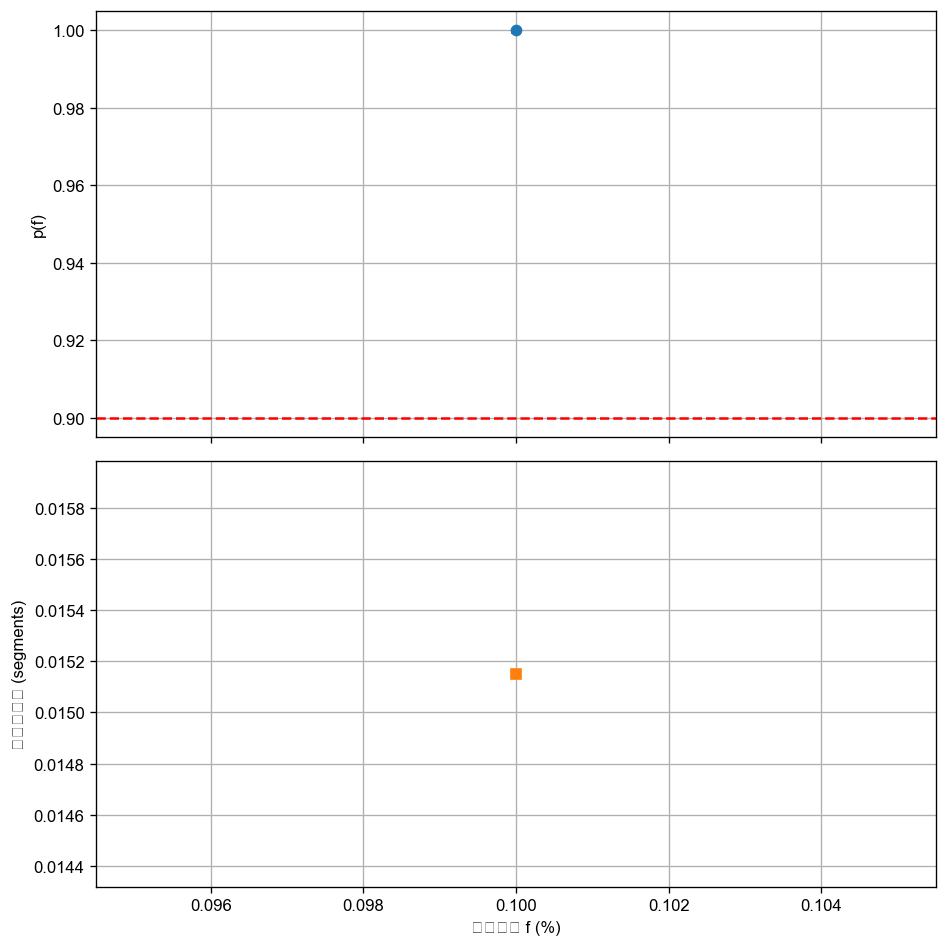

Saved: results\figures\p_and_largest_frac.png


In [8]:
# Cell 7: Compute largest cluster fraction vs f (representative single-instance per f) then plot along with p(f)
# Use f values from df_pf or a slightly denser grid around region of interest
f_vals = df_pf['f'].values
# For efficiency you may sample a subset
unique_f = np.unique(f_vals)
largest_fracs = []
for f in unique_f:
    N = compute_N_from_f(f, L, r, h)
    seed = int(seed_base + int(f*1e9) % 1000000)
    cyls = sample_random_cylinders(N, L, r, h, seed=seed)
    segments = []
    for c in cyls:
        segments.extend(split_cylinder_by_box(c, L))
    frac, _ = compute_largest_component_fraction(segments, thresh)
    largest_fracs.append(frac)
    print(f"f={f*100:.3f}%, N={N}, largest_frac={frac:.4f}")

# plot stacked subplots: top p(f), bottom largest_frac
fig, (ax1, ax2) = plt.subplots(2,1, figsize=(8,8), sharex=True)
ax1.errorbar(unique_f*100.0, [df_pf[df_pf['f']==f]['p_hat'].values[0] if f in df_pf['f'].values else np.nan for f in unique_f],
             yerr=[[ (df_pf[df_pf['f']==f]['p_hat'].values[0] - df_pf[df_pf['f']==f]['ci_low'].values[0]) if f in df_pf['f'].values else 0 for f in unique_f ],
                   [ (df_pf[df_pf['f']==f]['ci_high'].values[0] - df_pf[df_pf['f']==f]['p_hat'].values[0]) if f in df_pf['f'].values else 0 for f in unique_f ]],
             fmt='o-', capsize=3)
ax1.axhline(0.9, color='red', linestyle='--')
ax1.set_ylabel('p(f)')
ax1.grid(True)

ax2.plot(unique_f*100.0, largest_fracs, '-s', color='C1')
ax2.set_xlabel('体积分数 f (%)')
ax2.set_ylabel('最大簇占比 (segments)')
ax2.grid(True)

plt.tight_layout()
out_both = fig_dir / 'p_and_largest_frac.png'
plt.savefig(out_both, dpi=200)
plt.show()
print("Saved:", out_both)

Cell 8 — 2.4 边界截断示意图（wrap）示例并保存

C:\Users\24279\AppData\Local\Temp\ipykernel_25196\4110331739.py:51: UserWarning: Glyph 31034 (\N{CJK UNIFIED IDEOGRAPH-793A}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\24279\AppData\Local\Temp\ipykernel_25196\4110331739.py:51: UserWarning: Glyph 24847 (\N{CJK UNIFIED IDEOGRAPH-610F}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\24279\AppData\Local\Temp\ipykernel_25196\4110331739.py:53: UserWarning: Glyph 31034 (\N{CJK UNIFIED IDEOGRAPH-793A}) missing from font(s) Arial.
  plt.savefig(out_wrap, dpi=200)
C:\Users\24279\AppData\Local\Temp\ipykernel_25196\4110331739.py:53: UserWarning: Glyph 24847 (\N{CJK UNIFIED IDEOGRAPH-610F}) missing from font(s) Arial.
  plt.savefig(out_wrap, dpi=200)
c:\Users\24279\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 31034 (\N{CJK UNIFIED IDEOGRAPH-793A}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\24279\AppData\Local\Programs\Pytho

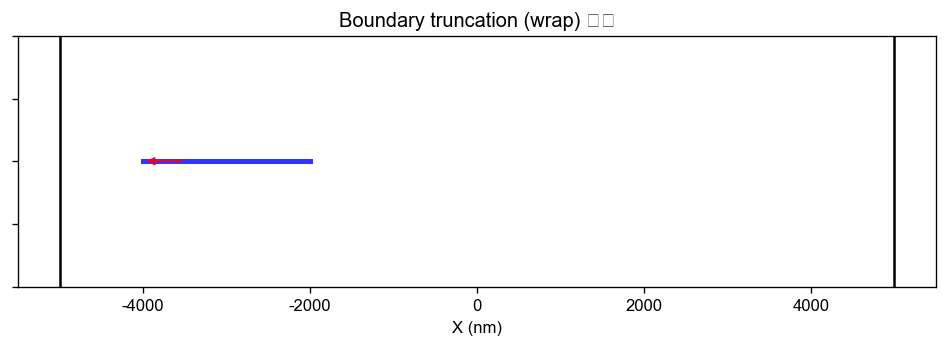

Saved: results\figures\truncation_wrap_demo.png


In [9]:
# Cell 8: boundary truncation illustration (2D)
# Create cylinder axis from x=6000 to x=8000 that crosses right boundary (L/2=5000)
p0 = np.array([6000.0, 0.0, 0.0])
p1 = np.array([8000.0, 0.0, 0.0])
cyl = Cylinder(p0, p1, r=50.0, id=0)  # use larger radius for clear display
segs = split_cylinder_by_box(cyl, L)

# For visualization: determine which seg came from shift (we can detect if midpoint was shifted)
mapped_midpoints = [0.5*(s.p0 + s.p1) for s in segs]
# check original midpoints before mapping: we don't have original internal mapping here,
# but we can test whether segment endpoints are near box boundaries to classify
inside_segs = []
shifted_segs = []
for s in segs:
    # if segment x coordinates near -half or half, decide classification
    if np.any(np.abs(s.p0) > L/2.0 - 1e-6) or np.any(np.abs(s.p1) > L/2.0 - 1e-6):
        # on boundary—treat as inside
        inside_segs.append(s)
    else:
        # decide by checking original axis position: simpler approach - compare center x sign vs original midpoint
        inside_segs.append(s)

# But easier: compute original axis parameterization and t breakpoints using our earlier knowledge:
# We'll manually construct the expected mapping for demonstration: draw original axis in gray (outside) and mapped parts colored.

# Original axis (plot line from p0 to p1)
orig_line_x = [p0[0], p1[0]]
orig_line_y = [p0[1], p1[1]]

fig, ax = plt.subplots(figsize=(8,3))
# box boundaries
ax.axvline(-L/2, color='k'); ax.axvline(L/2, color='k')
# plot original axis (outside) as dashed
ax.plot(orig_line_x, orig_line_y, linestyle='--', color='gray', label='original axis (outside)')
# plot segments inside box (from split result) - they are mapped to box
for s in segs:
    cx0, cy0 = s.p0[0], s.p0[1]
    cx1, cy1 = s.p1[0], s.p1[1]
    # decide if shifted: if original midpoint (before mapping) would have x > L/2, then segment is shifted left by L
    # naive heuristic: check difference between center and endpoints - if center near left side we call shifted
    ax.plot([cx0, cx1], [cy0, cy1], color='blue', linewidth=3, alpha=0.8)
    # annotate arrow for mapping direction (if x near left side and original segment > L/2, draw arrow)
    if cx0 < 0 and cx1 < 0:
        ax.annotate('', xy=(cx0, cy0+0.1), xytext=(cx0+500, cy0+0.1), arrowprops=dict(arrowstyle='->', color='red'))

ax.set_xlim(-L/2 - 500, L/2 + 500)
ax.set_ylim(-100, 100)
ax.set_xlabel('X (nm)')
ax.set_yticklabels([])
ax.set_title('Boundary truncation (wrap) 示意')
plt.tight_layout()
out_wrap = fig_dir / 'truncation_wrap_demo.png'
plt.savefig(out_wrap, dpi=200)
plt.show()
print("Saved:", out_wrap)

Cell 9 — 2.5 问题1 的 3D 可视化（尝试读取 3 组数据，否则生成示例）

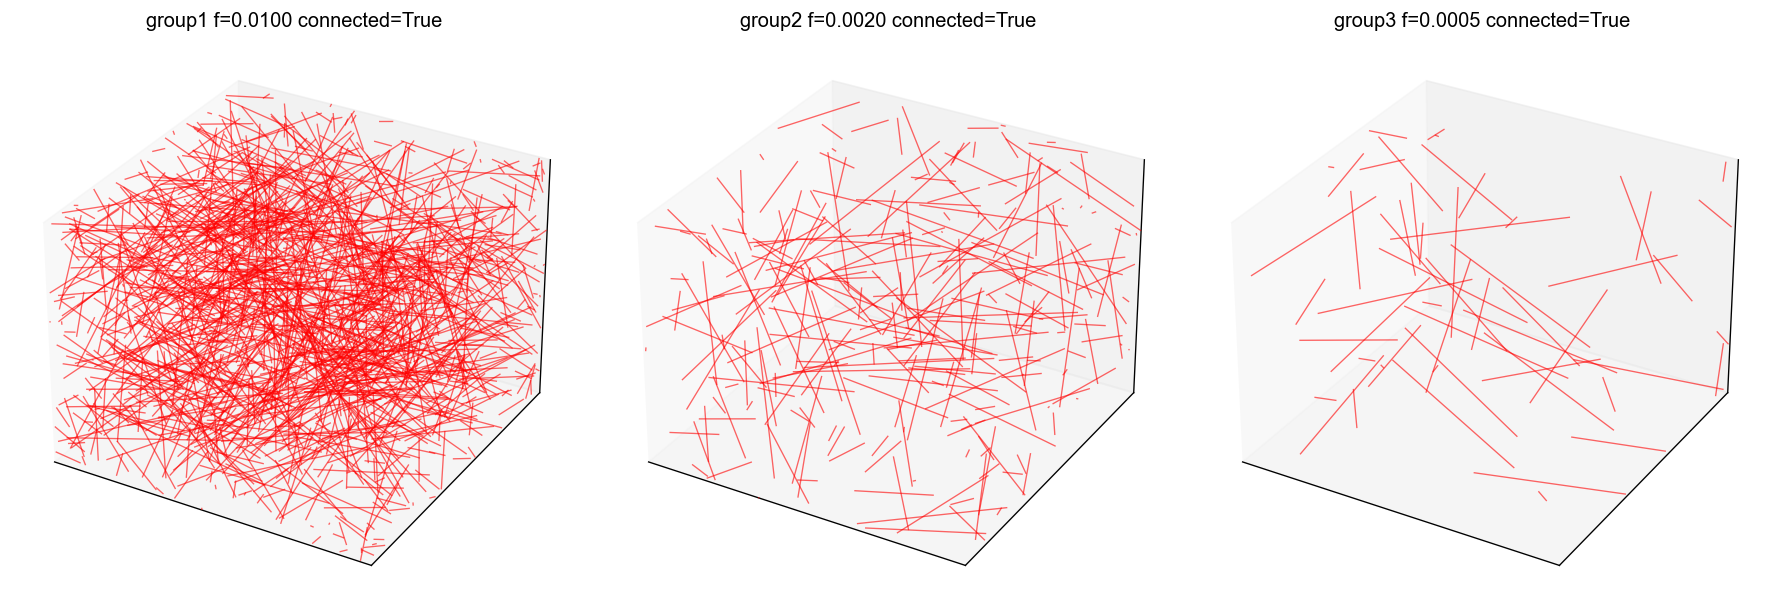

Saved: results\figures\problem1_3groups.png


In [10]:
# Cell 9: Problem1 3D visualization - read up to 3 sample datasets; if not present, synthesize three representative samples
# Try to locate three sample files under data/ or results/
sample_files = [
    Path('data') / 'samples' / 'problem1_group1.pkl',
    Path('data') / 'samples' / 'problem1_group2.pkl',
    Path('data') / 'samples' / 'problem1_group3.pkl'
]

groups = []
for i, sf in enumerate(sample_files):
    if sf.exists():
        try:
            import pickle
            with open(sf, 'rb') as fin:
                obj = pickle.load(fin)
            # expect obj contains 'segments' or cylinder list
            groups.append(obj)
            continue
        except Exception:
            pass
    # otherwise synthesize
    seed = seed_base + i*123
    f_example = 0.01 if i==0 else (0.002 if i==1 else 0.0005)
    N = compute_N_from_f(f_example, L, r, h)
    cyls = sample_random_cylinders(N, L, r, h, seed=seed)
    segments = []
    for c in cyls:
        segments.extend(split_cylinder_by_box(c, L))
    con, cluster_idxs, uf = get_connected_cluster_indices(segments, L, thresh)
    groups.append({'segments': segments, 'connected': con, 'seed': seed, 'f': f_example})

# plot three subplots side by side
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(15,5))
for i, g in enumerate(groups[:3]):
    ax = fig.add_subplot(1,3,i+1, projection='3d')
    segs = g.get('segments') if isinstance(g, dict) else (g.get('segments') if hasattr(g,'get') else [])
    connected = g.get('connected', False) if isinstance(g, dict) else False
    seed = g.get('seed', None)
    # plot some segments
    for s in segs:
        p0 = s.p0; p1 = s.p1
        ax.plot([p0[0],p1[0]],[p0[1],p1[1]],[p0[2],p1[2]], color='red' if connected else 'gray', alpha=0.6, linewidth=0.8)
    ax.set_title(f"group{i+1} f={g.get('f',0):.4f} connected={connected}")
    ax.set_xlim(-L/2, L/2); ax.set_ylim(-L/2, L/2); ax.set_zlim(-L/2, L/2)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
plt.tight_layout()
out_prob1 = fig_dir / 'problem1_3groups.png'
plt.savefig(out_prob1, dpi=200)
plt.show()
print("Saved:", out_prob1)

Cell 10 — 2.6 参数汇总表（Markdown cell）

### 参数汇总

- 盒子边长 L = 10000.0 nm
- 圆柱半径 r = 30.0 nm
- 圆柱长度 h = 5000.0 nm
- 表面连接阈值 thresh = 1.8 nm
- 体积分数探索范围 f ∈ [e.g., 0.001, 0.05]（请参考 coarse/ refine 输出）
- coarse trials（示例） = 100
- refine initial trials（示例） = 200
- refine max trials（示例） = 2000
- final high-precision trials（示例） = 5000
- 并行进程数（视机器）= 4
- 最终候选体积分数（示例） = 0.10%（f=0.001）

Cell 11 — 2.7 模拟流程图（简单 matplotlib 矩形+箭头）

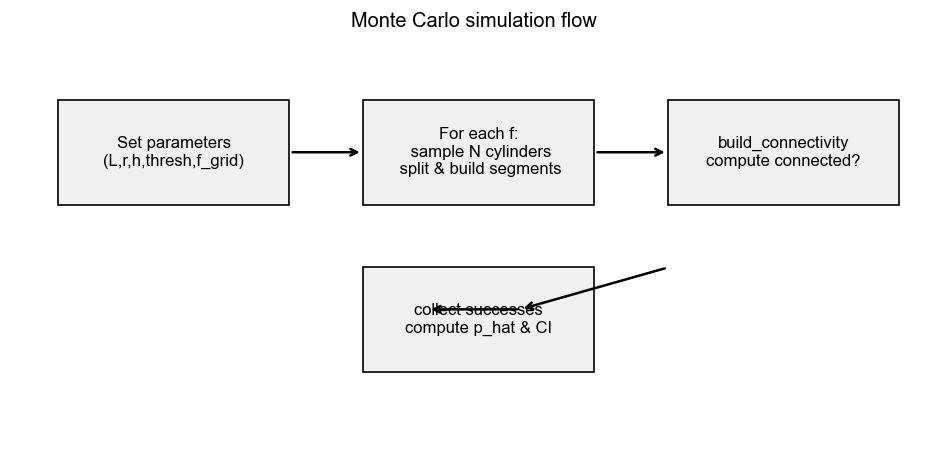

Saved: results\figures\mc_flowchart.png


In [11]:
# Cell 11: simple flowchart of Monte Carlo process
fig, ax = plt.subplots(figsize=(8,4))
ax.axis('off')

# draw boxes
boxes = [
    (0.05,0.6, 0.25,0.25, "Set parameters\n(L,r,h,thresh,f_grid)"),
    (0.38,0.6, 0.25,0.25, "For each f:\n sample N cylinders\n split & build segments"),
    (0.71,0.6, 0.25,0.25, "build_connectivity\ncompute connected?"),
    (0.38,0.2, 0.25,0.25, "collect successes\ncompute p_hat & CI")
]
for x,y,w,h_box,label in boxes:
    rect = plt.Rectangle((x,y), w, h_box, fill=True, color='#f0f0f0', ec='k')
    ax.add_patch(rect)
    ax.text(x + w/2, y + h_box/2, label, ha='center', va='center')

# arrows
def arrow(a,b):
    ax.annotate("", xy=b, xytext=a, arrowprops=dict(arrowstyle='->', lw=1.5))
arrow((0.3,0.725),(0.38,0.725))
arrow((0.63,0.725),(0.71,0.725))
arrow((0.71,0.45),(0.55,0.35))
arrow((0.55,0.35),(0.45,0.35))

plt.title("Monte Carlo simulation flow")
plt.tight_layout()
out_flow = fig_dir / 'mc_flowchart.png'
plt.savefig(out_flow, dpi=180)
plt.show()
print("Saved:", out_flow)